In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/ai_job_impact.csv")

In [2]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            2000 non-null   object 
 1   Age                    2000 non-null   int64  
 2   Gender                 2000 non-null   object 
 3   Education_Level        2000 non-null   object 
 4   Industry               2000 non-null   object 
 5   Job_Role               2000 non-null   object 
 6   Years_Experience       2000 non-null   int64  
 7   AI_Adoption_Level      2000 non-null   object 
 8   Automation_Risk        2000 non-null   object 
 9   Upskilling_Required    2000 non-null   object 
 10  Salary_Before_AI       2000 non-null   int64  
 11  Salary_After_AI        2000 non-null   int64  
 12  Job_Status             2000 non-null   object 
 13  Work_Hours_Per_Week    2000 non-null   int64  
 14  Remote_Work            2000 non-null   object 
 15  Job_

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03


In [3]:
df.isnull().sum()

Employee_ID              0
Age                      0
Gender                   0
Education_Level          0
Industry                 0
Job_Role                 0
Years_Experience         0
AI_Adoption_Level        0
Automation_Risk          0
Upskilling_Required      0
Salary_Before_AI         0
Salary_After_AI          0
Job_Status               0
Work_Hours_Per_Week      0
Remote_Work              0
Job_Satisfaction         0
Productivity_Change_%    0
dtype: int64

In [4]:
df.isin(["", " ", "N/A", "Unknown", "None"]).sum()


Employee_ID              0
Age                      0
Gender                   0
Education_Level          0
Industry                 0
Job_Role                 0
Years_Experience         0
AI_Adoption_Level        0
Automation_Risk          0
Upskilling_Required      0
Salary_Before_AI         0
Salary_After_AI          0
Job_Status               0
Work_Hours_Per_Week      0
Remote_Work              0
Job_Satisfaction         0
Productivity_Change_%    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.duplicated(subset="Employee_ID").sum()

np.int64(0)

In [7]:
df.dtypes

Employee_ID               object
Age                        int64
Gender                    object
Education_Level           object
Industry                  object
Job_Role                  object
Years_Experience           int64
AI_Adoption_Level         object
Automation_Risk           object
Upskilling_Required       object
Salary_Before_AI           int64
Salary_After_AI            int64
Job_Status                object
Work_Hours_Per_Week        int64
Remote_Work               object
Job_Satisfaction           int64
Productivity_Change_%    float64
dtype: object

In [8]:
for col in df.select_dtypes(include="object"):
    print(col, df[col].unique())

Employee_ID ['E0001' 'E0002' 'E0003' ... 'E1998' 'E1999' 'E2000']
Gender ['Female' 'Male' 'Other']
Education_Level ['Bachelor' 'High School' 'Master' 'PhD']
Industry ['Marketing' 'Manufacturing' 'IT' 'Education' 'Healthcare' 'Finance'
 'Retail']
Job_Role ['Content Creator' 'Quality Inspector' 'DevOps Engineer' 'Teacher'
 'Doctor' 'Technician' 'Administrator' 'Auditor' 'Professor' 'Nurse'
 'Store Manager' 'Accountant' 'Sales Associate' 'Digital Marketer'
 'Cashier' 'Data Analyst' 'Supervisor' 'Machine Operator' 'SEO Specialist'
 'Investment Analyst' 'Software Engineer']
AI_Adoption_Level ['High' 'Low' 'Medium']
Automation_Risk ['High' 'Low' 'Medium']
Upskilling_Required ['Yes' 'No']
Job_Status ['Replaced' 'Unchanged' 'Modified']
Remote_Work ['No' 'Yes']


In [9]:
for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip().str.capitalize()

In [10]:
df.describe()

,Age,Years_Experience,Salary_Before_AI,Salary_After_AI,Work_Hours_Per_Week,Job_Satisfaction,Productivity_Change_%
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,40.558000,16.663500,73942.072500,78428.642500,44.85100,6.020500,9.785820
std,10.786418,10.746675,26055.823793,29351.599013,5.71254,2.006263,17.187882
min,22.000000,0.000000,30036.000000,24447.000000,35.00000,3.000000,-19.990000
25%,32.000000,8.000000,51665.500000,54086.750000,40.00000,4.000000,-5.355000
50%,40.000000,16.000000,74620.000000,76820.500000,45.00000,6.000000,9.850000
75%,50.000000,26.000000,95418.250000,100730.250000,50.00000,8.000000,24.582500
max,59.000000,37.000000,119976.000000,161745.000000,54.00000,9.000000,39.990000


In [11]:
cols = ["Upskilling_Required", "Remote_Work"]
df[cols] = df[cols].apply(lambda col : col.map({"Yes": True, "No": False}).astype("boolean"))

In [12]:
df["Salary_Change"] = df["Salary_After_AI"] - df["Salary_Before_AI"]
df["Salary_Change_%"] = (df["Salary_Change"] / df["Salary_Before_AI"]) * 100

In [13]:
def experience_level(x):
    if x < 3:
        return "Junior"
    elif x < 7:
        return "Mid"
    else:
        return "Senior"

df["Experience_Level"] = df["Years_Experience"].apply(experience_level)

In [14]:
import numpy as np

conditions = [
    (df["Job_Status"] == "Replaced") | (df["Automation_Risk"] == "High"),
    (df["Job_Status"] == "Modified") | (df["Automation_Risk"] == "Medium"),
    (df["Job_Status"] == "Unchanged") & (df["Automation_Risk"] == "Low")
]

choices = ["High", "Medium", "Low"]
df["Impact_Level"] = np.select(conditions, choices, default="Medium")

In [15]:
df["AI_Adoption_Level"] = pd.Categorical(
    df["AI_Adoption_Level"],
    categories=["Low", "Medium", "High"],
    ordered=True
)
df["Job_Status"] = pd.Categorical(
    df["Job_Status"],
    categories=["Unchanged", "Modified", "Replaced"],
    ordered=True
)
df["Automation_Risk"] = pd.Categorical(
    df["Automation_Risk"],
    categories=["Low", "Medium", "High"],
    ordered=True
)

In [16]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Employee_ID            2000 non-null   object  
 1   Age                    2000 non-null   int64   
 2   Gender                 2000 non-null   object  
 3   Education_Level        2000 non-null   object  
 4   Industry               2000 non-null   object  
 5   Job_Role               2000 non-null   object  
 6   Years_Experience       2000 non-null   int64   
 7   AI_Adoption_Level      2000 non-null   category
 8   Automation_Risk        2000 non-null   category
 9   Upskilling_Required    2000 non-null   boolean 
 10  Salary_Before_AI       2000 non-null   int64   
 11  Salary_After_AI        2000 non-null   int64   
 12  Job_Status             2000 non-null   category
 13  Work_Hours_Per_Week    2000 non-null   int64   
 14  Remote_Work            2000 non-null   b

,Age,Years_Experience,Salary_Before_AI,Salary_After_AI,Work_Hours_Per_Week,Job_Satisfaction,Productivity_Change_%,Salary_Change,Salary_Change_%
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000
mean,40.558000,16.663500,73942.072500,78428.642500,44.85100,6.020500,9.785820,4486.570000,6.046144
std,10.786418,10.746675,26055.823793,29351.599013,5.71254,2.006263,17.187882,9833.709699,12.284015
min,22.000000,0.000000,30036.000000,24447.000000,35.00000,3.000000,-19.990000,-21292.000000,-19.989659
25%,32.000000,8.000000,51665.500000,54086.750000,40.00000,4.000000,-5.355000,-1170.500000,-1.908181
50%,40.000000,16.000000,74620.000000,76820.500000,45.00000,6.000000,9.850000,2594.000000,4.367248
75%,50.000000,26.000000,95418.250000,100730.250000,50.00000,8.000000,24.582500,8160.250000,12.057171
max,59.000000,37.000000,119976.000000,161745.000000,54.00000,9.000000,39.990000,45789.000000,39.912248


In [17]:
df.to_csv("../data/ai_job_impact_cleaned.csv", index=False)

## Impact global de l’IA

### Q1. Les salaires augmentent-ils ou baissent-ils ?

In [18]:
salary_before_ai = df["Salary_Before_AI"].mean().round(2)
salary_after_ai = df["Salary_After_AI"].mean().round(2)
salary_change_pct = df["Salary_Change_%"].mean().round(2)
salary_before_ai, salary_after_ai, salary_change_pct

(np.float64(73942.07), np.float64(78428.64), np.float64(6.05))

Augmentation moyenne du salaire de 6%, qui suggère un impact global positif de l'IA. 

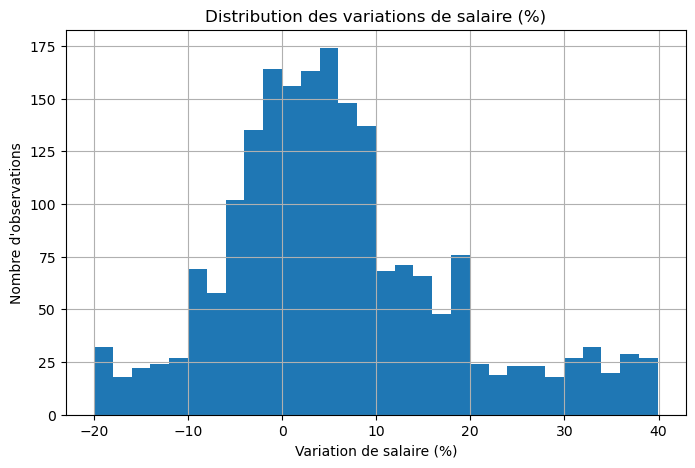

In [19]:
plt.figure(figsize=(8,5))

df["Salary_Change_%"].hist(bins=30)

plt.title("Distribution des variations de salaire (%)")
plt.xlabel("Variation de salaire (%)")
plt.ylabel("Nombre d'observations")

plt.show()

In [20]:
df["Salary_Change_%"].describe()

count    2000.000000
mean        6.046144
std        12.284015
min       -19.989659
25%        -1.908181
50%         4.367248
75%        12.057171
max        39.912248
Name: Salary_Change_%, dtype: float64

Tendance globale à la hausse mais 25% en perte de salaire (jusqu'à -20%) et certains y gagnent beaucoup (avec un max de +40%). Impact inégal de l'IA selon les métiers et/ou les industries.

### Q2. Répartition des statuts d’emploi

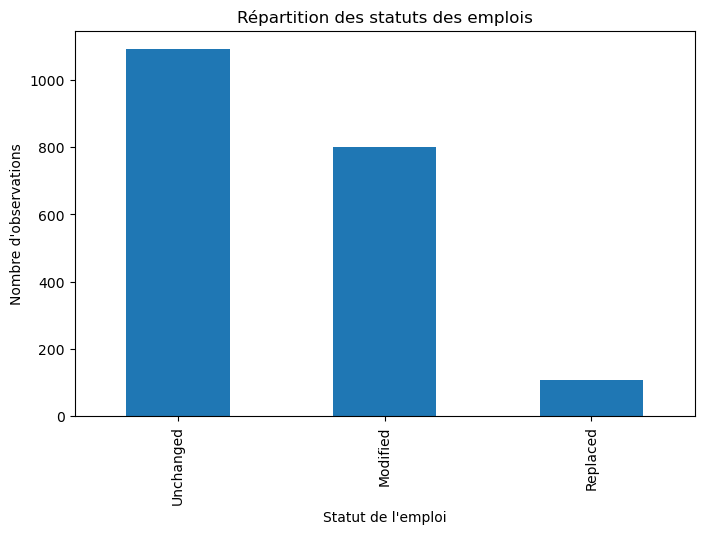

In [21]:
plt.figure(figsize=(8,5))

df["Job_Status"].value_counts().plot(kind="bar")

plt.title("Répartition des statuts des emplois")
plt.xlabel("Statut de l'emploi")
plt.ylabel("Nombre d'observations")

plt.show()

Une grande majorité des emplois sont soit inchangés, soit modifiés. Cela indique que l’IA a principalement un effet de transformation des métiers, plutôt qu’un effet de remplacement direct.

##  Impact par industrie

### Q3. Quelles industries sont les plus impactées ?

In [22]:
salary_change_pct_by_industry = df.groupby("Industry")["Salary_Change_%"].mean().sort_values(ascending=False)
salary_change_pct_by_industry

Industry
Healthcare       7.591661
Retail           6.625069
It               6.225764
Marketing        6.080251
Education        6.063224
Finance          5.233065
Manufacturing    4.696661
Name: Salary_Change_%, dtype: float64

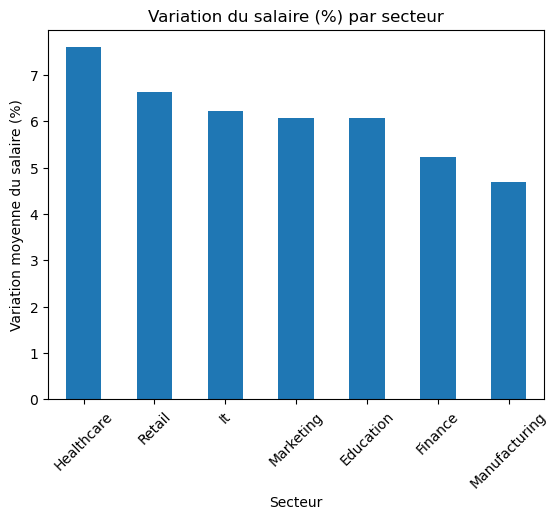

In [23]:
plt.figure()

salary_change_pct_by_industry.plot(kind="bar")

plt.title("Variation du salaire (%) par secteur")
plt.xlabel("Secteur")
plt.ylabel("Variation moyenne du salaire (%)")

plt.xticks(rotation=45)

plt.show()

In [24]:
df["Is_Replaced"] = (df["Job_Status"] == "Replaced")
(df.groupby("Industry")["Is_Replaced"].mean() * 100).sort_values(ascending=True)

Industry
Manufacturing    3.728814
Healthcare       4.074074
Retail           4.797048
It               5.369128
Finance          6.000000
Education        6.143345
Marketing        6.959707
Name: Is_Replaced, dtype: float64

In [25]:
job_status_by_industry = (pd.crosstab(df["Industry"], df["Job_Status"], normalize="index") * 100).round(2)
job_status_by_industry

Job_Status,Unchanged,Modified,Replaced
Industry,,,
Education,60.07,33.79,6.14
Finance,51.67,42.33,6.00
Healthcare,54.44,41.48,4.07
It,48.99,45.64,5.37
Manufacturing,62.37,33.90,3.73
Marketing,50.92,42.12,6.96
Retail,53.87,41.33,4.80


<Figure size 1000x600 with 0 Axes>

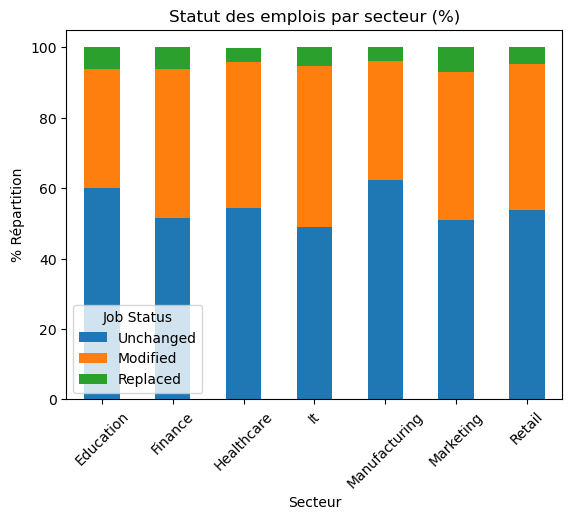

In [26]:
plt.figure(figsize=(10,6))

job_status_by_industry.plot(kind="bar", stacked=True)

plt.title("Statut des emplois par secteur (%)")
plt.xlabel("Secteur")
plt.ylabel("% Répartition")

plt.xticks(rotation=45)

plt.legend(title="Job Status")

plt.show()

Les secteurs de la santé, du retail et de l’IT présentent les plus fortes hausses de salaires. La santé et le retail figurent également parmi les industries les moins exposées au remplacement, ce qui suggère que les métiers moins automatisables sont à la fois mieux rémunérés et plus protégés face à l’IA.

À l’inverse, le secteur IT enregistre une forte hausse des salaires malgré un niveau d’exposition plus élevé, ce qui peut s’expliquer par une demande accrue en compétences techniques liées à l’IA.

## Impact par métier

### Q4. Quels métiers gagnent ou perdent le plus ?

In [27]:
salary_by_role = df.groupby("Job_Role")["Salary_Change_%"].mean().sort_values()
top_roles = salary_by_role.tail(10).sort_values(ascending=False)
bottom_roles = salary_by_role.head(10)
top_roles, bottom_roles

(Job_Role
 Doctor              8.435574
 Data analyst        8.084790
 Sales associate     7.977870
 Nurse               7.723615
 Digital marketer    7.009918
 Store manager       6.923738
 Professor           6.915650
 Seo specialist      6.872043
 Technician          6.643345
 Teacher             6.152210
 Name: Salary_Change_%, dtype: float64,
 Job_Role
 Supervisor            3.764637
 Content creator       4.109907
 Software engineer     4.536437
 Machine operator      4.542030
 Investment analyst    4.776857
 Cashier               5.001995
 Accountant            5.057263
 Administrator         5.090208
 Quality inspector     5.626625
 Devops engineer       5.701316
 Name: Salary_Change_%, dtype: float64)

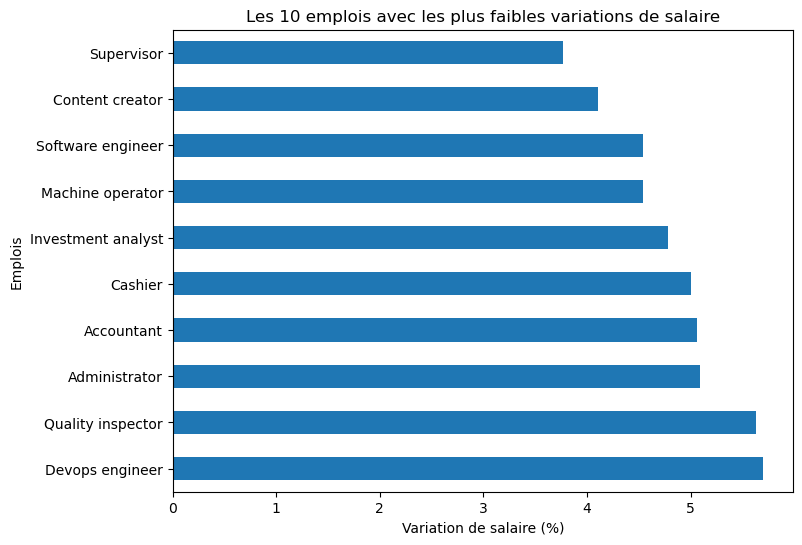

In [28]:
plt.figure(figsize=(8,6))

bottom_roles.sort_values(ascending=False).plot(kind="barh")

plt.title("Les 10 emplois avec les plus faibles variations de salaire")
plt.xlabel("Variation de salaire (%)")
plt.ylabel("Emplois")

plt.show()

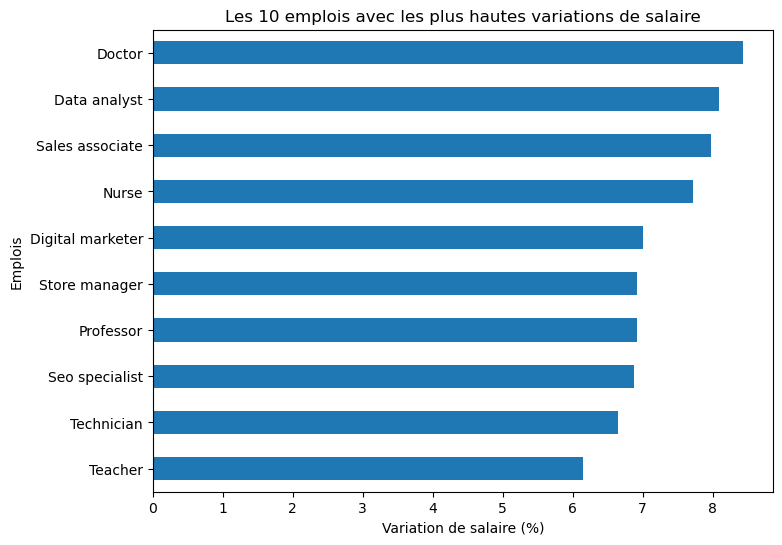

In [29]:
plt.figure(figsize=(8,6))

top_roles.sort_values(ascending=True).plot(kind="barh")

plt.title("Les 10 emplois avec les plus hautes variations de salaire")
plt.xlabel("Variation de salaire (%)")
plt.ylabel("Emplois")

plt.show()

Les métiers de la santé et certains rôles analytiques ou commerciaux enregistrent les plus fortes hausses de salaires, avec des augmentations supérieures à 7–8 %.
À l’inverse, d’autres fonctions comme les postes de supervision, de production ou certains rôles techniques présentent des hausses plus modérées, autour de 4–5 %.

Cela suggère que l’impact de l’IA est globalement positif sur les salaires, mais qu’il varie selon les compétences mobilisées, les métiers les plus spécialisés ou à forte dimension humaine bénéficiant davantage de cette dynamique.
Ces résultats sont cohérents avec l’analyse par industrie, où les secteurs de la santé et du retail présentent également de fortes hausses de salaires.

## Expérience vs impact

###  Q5. L’expérience protège-t-elle ?

In [30]:
job_status_by_exp_level = (pd.crosstab(df["Experience_Level"], df["Job_Status"], normalize="index") * 100).round(2)
job_status_by_exp_level

Job_Status,Unchanged,Modified,Replaced
Experience_Level,,,
Junior,57.20,38.52,4.28
Mid,59.24,38.04,2.72
Senior,53.69,40.54,5.77


<Figure size 800x500 with 0 Axes>

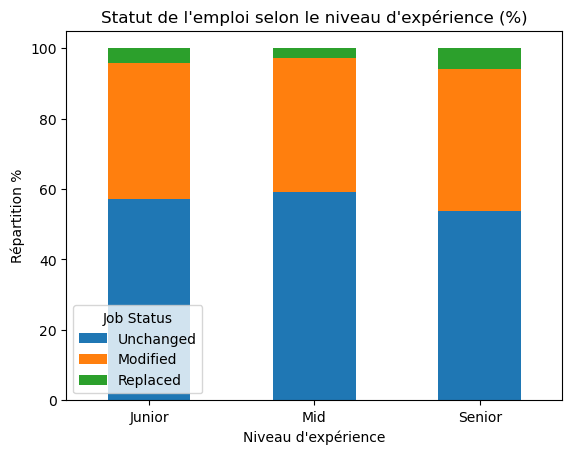

In [31]:
plt.figure(figsize=(8,5))

job_status_by_exp_level.plot(kind="bar", stacked=True)

plt.title("Statut de l'emploi selon le niveau d'expérience (%)")
plt.xlabel("Niveau d'expérience")
plt.ylabel("Répartition %")

plt.xticks(rotation=0)
plt.legend(title="Job Status")

plt.show()

In [32]:
salary_change_by_exp_level = df.groupby("Experience_Level")["Salary_Change_%"].mean().round(2).sort_values(ascending=False)
salary_change_by_exp_level

Experience_Level
Junior    6.18
Senior    6.10
Mid       5.42
Name: Salary_Change_%, dtype: float64

Contrairement aux attentes, les profils seniors sont les plus exposés au remplacement, ce qui peut s’expliquer par leur coût plus élevé et la transformation de certaines fonctions stratégiques. Les profils intermédiaires apparaissent comme les plus résilients. Malgré cela, l’ensemble des niveaux d’expérience bénéficie d’une hausse de salaire, suggérant un effet globalement positif mais différencié de l’IA.
Ces écarts restent toutefois modérés, ce qui suggère que le niveau d’expérience n’est pas le principal facteur déterminant de l’impact de l’IA.

## IA & automatisation

### Q6. Corrélation adoption IA vs impact

In [33]:
job_status_by_automation_risk = (pd.crosstab(df["Automation_Risk"], df["Job_Status"], normalize="index") * 100).round(2)
job_status_by_automation_risk

Job_Status,Unchanged,Modified,Replaced
Automation_Risk,,,
Low,100.00,0.0,0.00
Medium,0.00,100.0,0.00
High,64.96,19.5,15.54


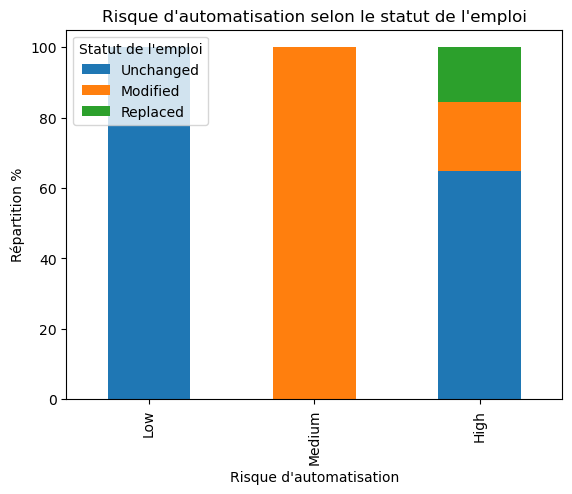

In [34]:
job_status_by_automation_risk.plot(kind="bar", stacked=True)

plt.title("Risque d'automatisation selon le statut de l'emploi")
plt.xlabel("Risque d'automatisation")
plt.ylabel("Répartition %")
plt.legend(title="Statut de l'emploi")

plt.show()

In [35]:
job_status_by_ai_adoption_lvl = (pd.crosstab(df["AI_Adoption_Level"], df["Job_Status"], normalize="index")* 100).round(2)
job_status_by_ai_adoption_lvl 

Job_Status,Unchanged,Modified,Replaced
AI_Adoption_Level,,,
Low,64.72,35.28,0.00
Medium,68.98,31.02,0.00
High,32.06,52.91,15.04


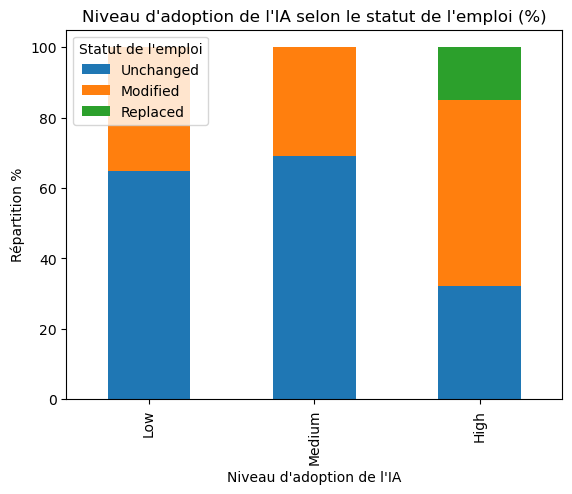

In [36]:
job_status_by_ai_adoption_lvl.plot(kind="bar", stacked=True)

plt.title("Niveau d'adoption de l'IA selon le statut de l'emploi (%)")
plt.xlabel("Niveau d'adoption de l'IA")
plt.ylabel("Répartition %")
plt.legend(title="Statut de l'emploi")

plt.show()

Le risque d'automatisation apparaît comme un bon prédicteur du statut des emplois , tandis que l'adoption réelle de l'IA entraîne principalement une transformation progressive, avec un remplacement limité aux métiers les plus exposés et aux contextes de forte adoption.

## Upskilling

### Q7. L’upskilling protège-t-il ?

In [37]:
job_status_upskilling = (pd.crosstab(df["Upskilling_Required"], df["Job_Status"], normalize="index") *100).round(2)
job_status_upskilling

Job_Status,Unchanged,Modified,Replaced
Upskilling_Required,,,
False,54.93,39.63,5.44
True,54.39,40.45,5.17


In [38]:
salary_change_upskilling = df.groupby("Upskilling_Required")["Salary_Change_%"].mean().round(2)
salary_change_upskilling

Upskilling_Required
False    5.59
True     6.48
Name: Salary_Change_%, dtype: float64

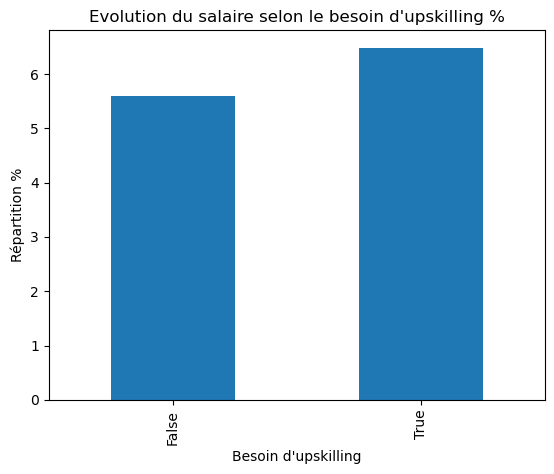

In [39]:
salary_change_upskilling.plot(kind="bar")
plt.title("Evolution du salaire selon le besoin d'upskilling %")
plt.xlabel("Besoin d'upskilling")
plt.ylabel("Répartition %")

plt.show()

Les métiers nécessitant un upskilling sont davantages modifiés que remplacés, ce qui suggère que l'acquisition de nouvelles compétences permet de s'adapter aux transformations apportées par l'IA. 
De plus ces emplois bénéficient d'une évolution salariale plus favorable.

## Productivité & satisfaction

### Q8. L’IA améliore-t-elle la productivité ?

In [40]:
productivity_change_pct_by_ai_adoption_level = df.groupby("AI_Adoption_Level", observed=True)["Productivity_Change_%"].mean().round(2)
productivity_change_pct_by_ai_adoption_level

AI_Adoption_Level
Low        8.03
Medium    10.17
High      10.95
Name: Productivity_Change_%, dtype: float64

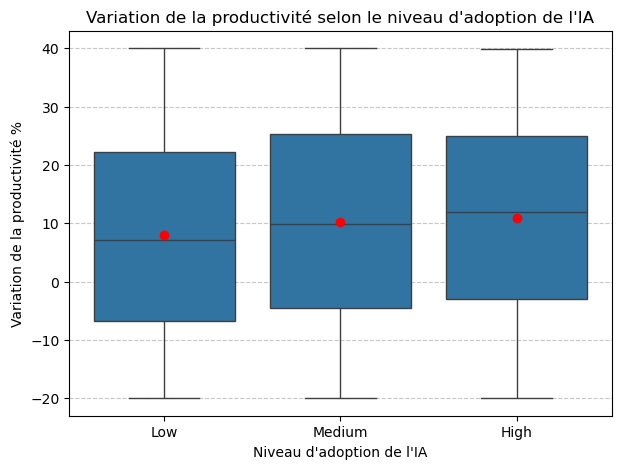

In [41]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="AI_Adoption_Level",
    y="Productivity_Change_%",
    data=df
)
plt.scatter(
    x=range(len(productivity_change_pct_by_ai_adoption_level)),
    y=productivity_change_pct_by_ai_adoption_level,
    color="red",
    zorder=10
)

plt.title("Variation de la productivité selon le niveau d'adoption de l'IA")
plt.xlabel("Niveau d'adoption de l'IA")
plt.ylabel("Variation de la productivité %")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

Une adoption plus élevée de l’IA est associée à des gains de productivité plus importants. Des pertes persistent toutefois, mais leur ampleur diminue avec l’adoption.

### Q9. Impact sur la satisfaction

In [42]:
satisfaction_by_job_status = df.groupby("Job_Status", observed=True)["Job_Satisfaction"].mean().round(2)
satisfaction_by_job_status

Job_Status
Unchanged    6.03
Modified     5.99
Replaced     6.09
Name: Job_Satisfaction, dtype: float64

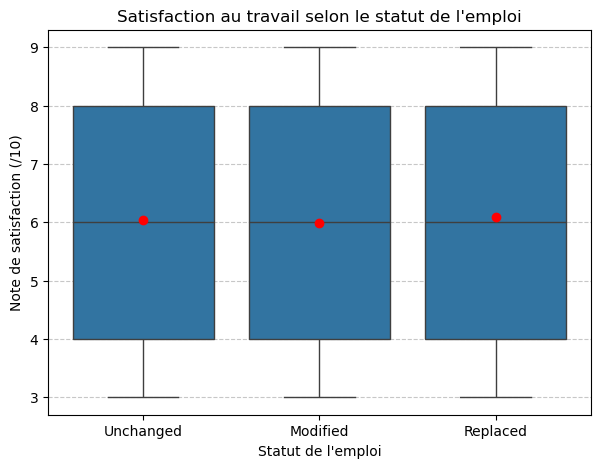

In [43]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Job_Status",
    y="Job_Satisfaction",
    data=df
)
plt.scatter(
    x=range(len(satisfaction_by_job_status)),
    y=satisfaction_by_job_status,
    color="red",
    zorder=10
)
plt.title("Satisfaction au travail selon le statut de l'emploi")
plt.xlabel("Statut de l'emploi")
plt.ylabel("Note de satisfaction (/10)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.xticks(rotation=0)

plt.show()

Le statut des emplois n’a pas d’impact significatif sur la satisfaction, les niveaux restant globalement stables.

Cette analyse met en évidence que l’intelligence artificielle a un impact globalement positif sur le marché du travail, mais de manière hétérogène selon les contextes.
- Sur le plan économique, les salaires augmentent en moyenne, bien que cette progression soit inégale selon les métiers et les secteurs. Les gains de productivité suivent également une tendance positive avec le niveau d’adoption de l’IA, tout en restant variables selon les situations.
- Sur le plan de l’emploi, l’IA transforme davantage les métiers qu’elle ne les remplace. La majorité des emplois restent inchangés ou sont modifiés, et le remplacement demeure limité aux contextes de forte adoption et aux métiers à haut risque d’automatisation.
Par ailleurs, le risque d’automatisation apparaît comme un bon prédicteur théorique du statut des emplois, tandis que l’adoption réelle de l’IA révèle un impact plus progressif et nuancé.
Enfin, l’upskilling ne semble pas protéger significativement contre le remplacement, mais est associé à une légère amélioration des salaires, suggérant une valorisation des compétences plutôt qu’un effet direct sur la sécurité de l’emploi.

Dans l’ensemble, ces résultats indiquent que l’IA agit principalement comme un levier de transformation et d’amélioration de la performance, avec des effets différenciés selon les métiers, les secteurs et les niveaux d’adoption.

In [ ]:
df.to_csv("../data/cleaned/ai_job_impact_cleaned.csv")